In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

In [2]:
def entropy(x, b):
    s = 0
    for p in x:
        if p > 0:
            s += -p * math.log(p, b)
    return s

def visualize_regions_keras(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)
    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T
    B = model.predict(A, verbose=0).argmax(axis=1)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)
    prob_2D = model.predict(A, verbose=0)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)
    return B, S

## Create data

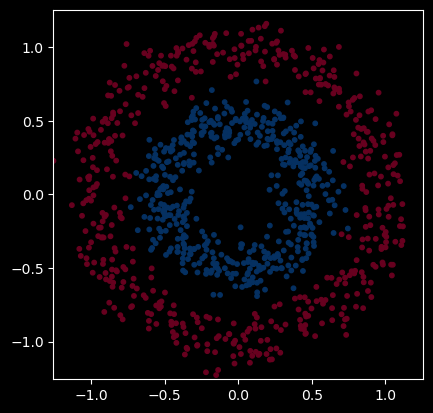

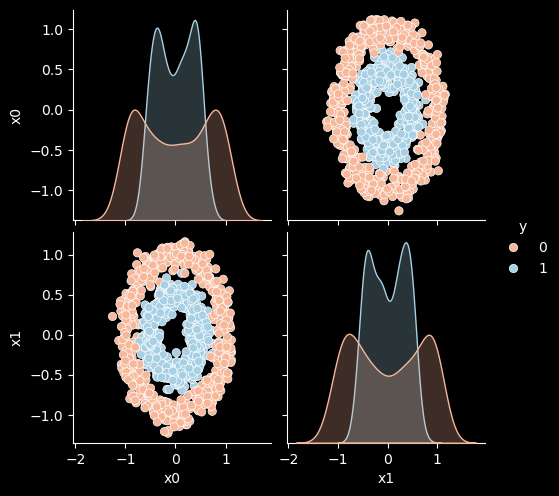

In [3]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 3

if   choice == 0:
    X, y = make_blobs(n_samples=n_samples, n_features=2, centers=2, cluster_std=5, random_state=10)
elif choice == 1:
    X, y = make_classification(n_samples=n_samples, n_features=2, n_informative=2,
                                n_redundant=0, n_clusters_per_class=1, n_classes=3, random_state=41)
elif choice == 2:
    X, y = make_moons(n_samples=n_samples, noise=0.2, random_state=42)
elif choice == 3:
    X, y = make_circles(n_samples=n_samples, noise=0.1, factor=0.5, random_state=42)

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

n_classes = np.unique(y).shape[0]

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='RdBu')
plt.xlim(-MAX, MAX); plt.ylim(-MAX, MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame({'x0': X[:,0], 'x1': X[:,1], 'y': y})
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## Modeling

## Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

## Keras — Functional API

The **Functional API** allows building models with non-sequential data flows — multiple inputs, multiple outputs, shared layers, and skip connections.

Here we build a residual-like architecture: the output of the first hidden layer is **concatenated** with the original input before feeding into the next layer. This gives later layers direct access to raw features alongside learned representations.

```
inputs  ──►  Dense(3, relu)  ──►  Concatenate  ──►  Dense(2, relu)  ──►  Dense(K, softmax)
    └─────────────────────────────────────────────┘
```

In [5]:
from keras.models import Model
from keras.layers import *
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

n_features = X.shape[1]
n_classes  = np.unique(y).shape[0]

# Define input
inputs = Input(shape=(n_features,))

# First dense layer
x = Dense(3, activation='relu')(inputs)

# Skip connection: concatenate dense output with original input
x = Concatenate()([x, inputs])

# Second dense layer
x = Dense(2, activation='relu')(x)

# Output
outputs = Dense(n_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3)         │          9 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5)         │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │         12 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │          6 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=0,
    callbacks=[early_stopping]
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


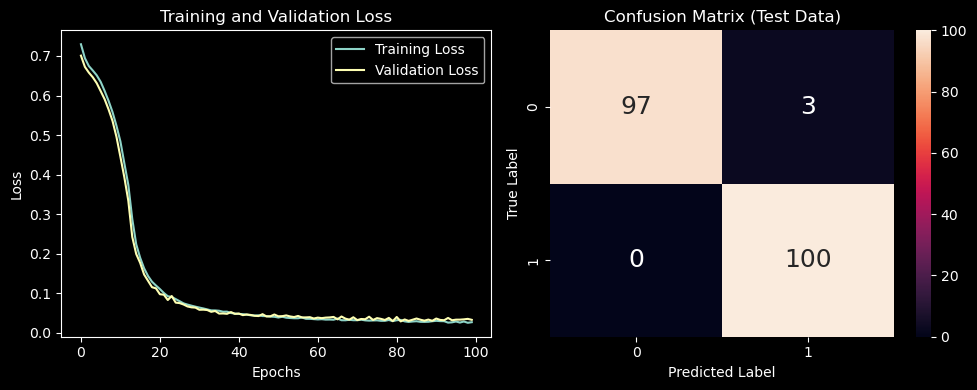

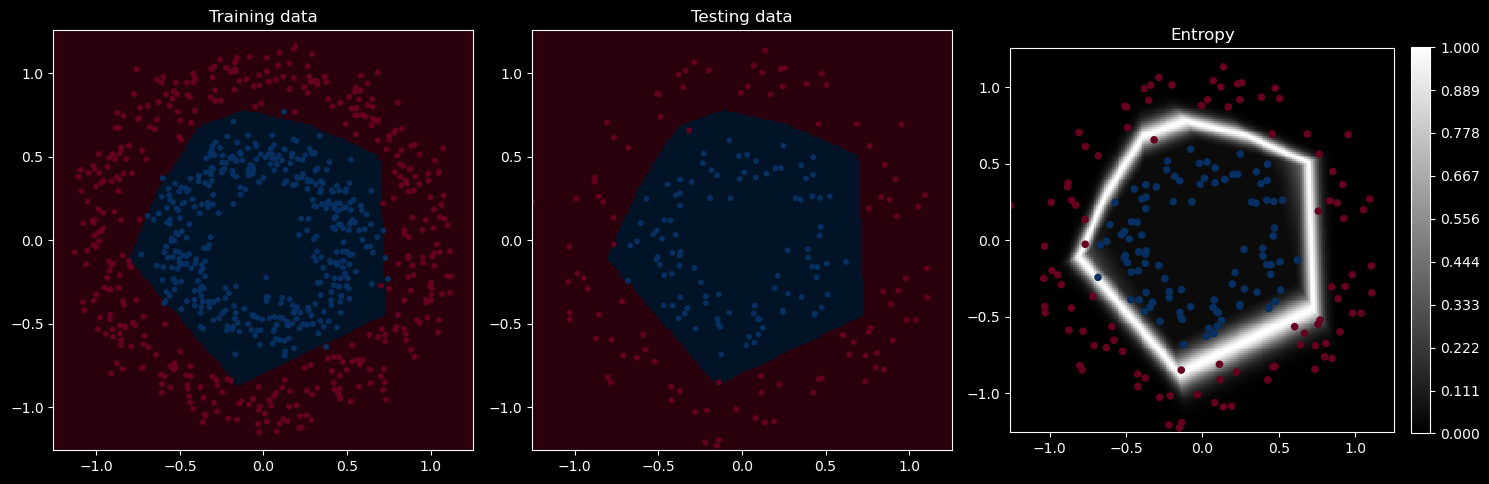

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       100
           1       0.97      1.00      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_train_pred = model.predict(X_train).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].legend()

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], vmin=0, annot_kws={'size': 18})
axes[1].set_title('Confusion Matrix (Test Data)')
axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

B, S = visualize_regions_keras(model, MAX, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
extent = [-MAX, MAX, -MAX, MAX]
cmap = 'RdBu'

axes[0].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap)
axes[0].set_aspect('equal'); axes[0].set_title('Training data')

axes[1].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap)
axes[1].set_aspect('equal'); axes[1].set_title('Testing data')

im = axes[2].imshow(S, interpolation='none', extent=extent, cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap)
axes[2].set_aspect('equal'); axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(n_classes, 2), 10))

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred))